In [34]:
import pyarrow.dataset as ds

dataset = ds.dataset(r"C:\Users\mnapo\Desktop\IBKR Stuff\ALL_DATA\cleaned\ticks_20260430.parquet", format="parquet")
df = dataset.head(40_000).to_pandas()

In [35]:
df

,"('base', 'timestamp')","('base', 'trigger_symbol')","('EUR-USD', 'asset_class')","('EUR-USD', 'exchange')","('EUR-USD', 'bid')","('EUR-USD', 'ask')","('EUR-USD', 'bid_size')","('EUR-USD', 'ask_size')","('EUR-USD', 'tradable')","('GBP-USD', 'asset_class')",...,"('GBL', 'bid_size')","('GBL', 'ask_size')","('GBL', 'tradable')","('CONF', 'asset_class')","('CONF', 'exchange')","('CONF', 'bid')","('CONF', 'ask')","('CONF', 'bid_size')","('CONF', 'ask_size')","('CONF', 'tradable')"
0,2026-04-30 00:00:00.007060-04:00,QCOM,FX,IDEALPRO,1.16659,1.16661,1000000.0,2000000.0,True,FX,...,105.0,74.0,True,RATE,EUREX,154.5,155.03,1.701412e+38,1.701412e+38,False
1,2026-04-30 00:00:00.008058-04:00,QCOM,FX,IDEALPRO,1.16659,1.16661,1000000.0,2000000.0,True,FX,...,105.0,74.0,True,RATE,EUREX,154.5,155.03,1.701412e+38,1.701412e+38,False
2,2026-04-30 00:00:00.051432-04:00,USD-CNH,FX,IDEALPRO,1.16659,1.16661,1000000.0,2000000.0,True,FX,...,105.0,74.0,True,RATE,EUREX,154.5,155.03,1.701412e+38,1.701412e+38,False
3,2026-04-30 00:00:00.051432-04:00,USD-JPY,FX,IDEALPRO,1.16659,1.16661,1000000.0,2000000.0,True,FX,...,105.0,74.0,True,RATE,EUREX,154.5,155.03,1.701412e+38,1.701412e+38,False
4,2026-04-30 00:00:00.051432-04:00,USD-JPY,FX,IDEALPRO,1.16659,1.16661,1000000.0,2000000.0,True,FX,...,105.0,74.0,True,RATE,EUREX,154.5,155.03,1.701412e+38,1.701412e+38,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,2026-04-30 00:05:43.391973-04:00,USD-MXN,FX,IDEALPRO,1.16634,1.16635,1500000.0,1000000.0,True,FX,...,24.0,164.0,True,RATE,EUREX,154.5,155.03,1.701412e+38,1.701412e+38,False
39996,2026-04-30 00:05:43.391973-04:00,NZD-USD,FX,IDEALPRO,1.16634,1.16635,1500000.0,1000000.0,True,FX,...,24.0,164.0,True,RATE,EUREX,154.5,155.03,1.701412e+38,1.701412e+38,False
39997,2026-04-30 00:05:43.419989-04:00,NQ,FX,IDEALPRO,1.16634,1.16635,1500000.0,1000000.0,True,FX,...,24.0,164.0,True,RATE,EUREX,154.5,155.03,1.701412e+38,1.701412e+38,False
39998,2026-04-30 00:05:43.420991-04:00,NQ,FX,IDEALPRO,1.16634,1.16635,1500000.0,1000000.0,True,FX,...,24.0,164.0,True,RATE,EUREX,154.5,155.03,1.701412e+38,1.701412e+38,False


In [36]:
df = df.set_index("('base', 'timestamp')")
df = df.resample("1s").last().ffill()

In [37]:
df["test"] = ((df["('EUR-USD', 'bid')"] + df["('EUR-USD', 'ask')"]) / 2).pct_change()
df["width"] = df["('EUR-USD', 'bid')"] - df["('EUR-USD', 'ask')"]

In [38]:
test = df["test"].dropna()

In [39]:
import numpy as np

x = np.asarray(test, dtype=float)

y = x[1:]      # X_t
X = x[:-1]     # X_{t-1}

# fit: X_t = phi * X_{t-1} + eps_t
phi = np.dot(X, y) / np.dot(X, X)

print("AR(1) coeff:", phi)

AR(1) coeff: -0.06044642399208216


In [40]:
eps = y - (phi * X)
eps_var = np.var(eps, ddof=2)   # estimated innovation variance
eps_std = np.std(eps, ddof=2)

print("eps variance:", eps_var)
print("eps std:", eps_std)

eps variance: 1.0465995491523019e-10
eps std: 1.0230344809205123e-05


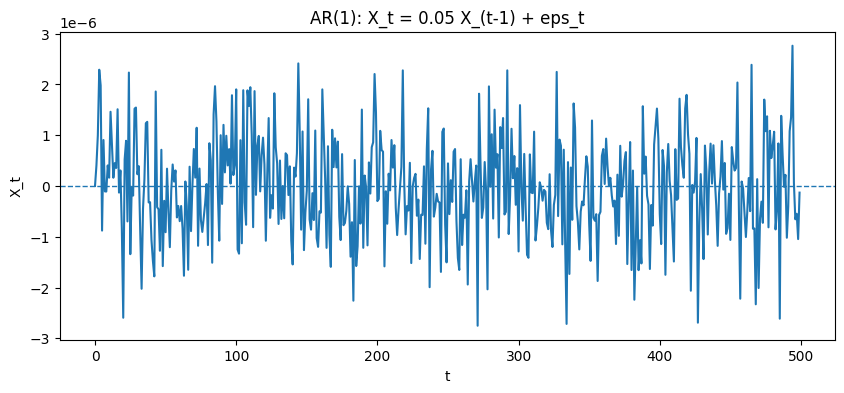

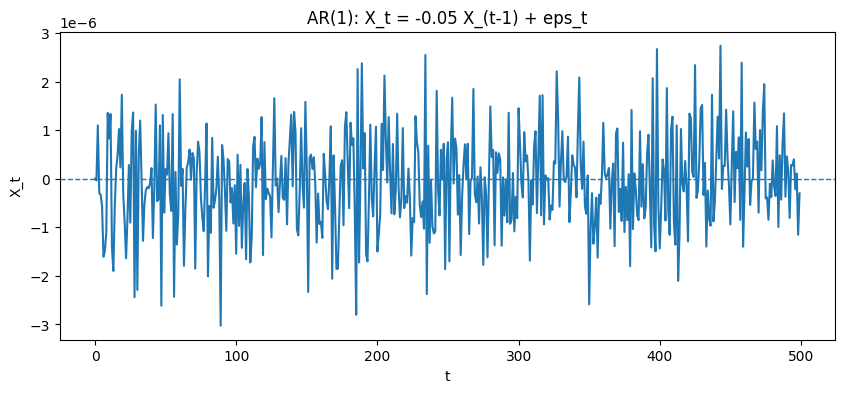

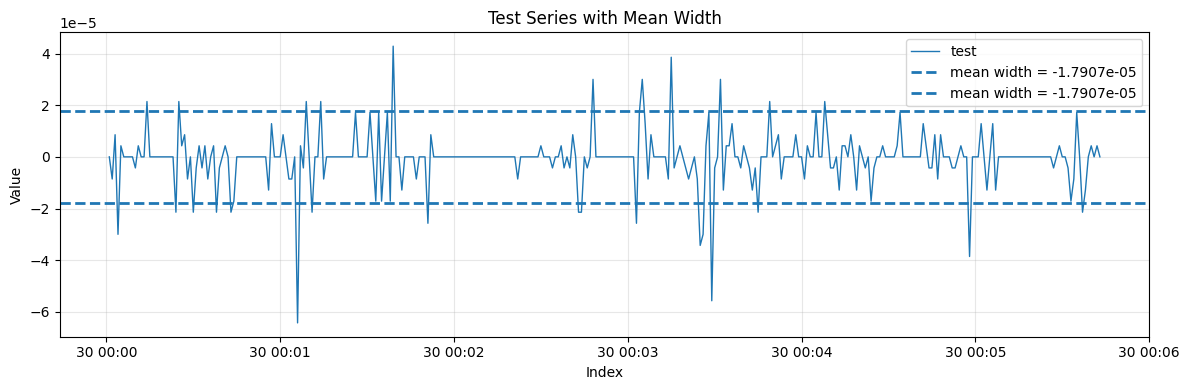

In [42]:
import numpy as np
import matplotlib.pyplot as plt

mean = df["width"].mean()

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(test, linewidth=1, label="test")
ax.axhline(mean, linestyle="--", linewidth=2, label=f"mean width = {mean:.6g}")
ax.axhline(-mean, linestyle="--", linewidth=2, label=f"mean width = {mean:.6g}")

ax.set_title("Test Series with Mean Width")
ax.set_xlabel("Index")
ax.set_ylabel("Value")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()